# Notebook 03

## Gram Matrix Analysis

Goal

Study the physical meaning of the Gram Matrix.

Questions

1. Why is G = SᴴS ?

2. What does each element mean?

3. Why is the diagonal the signal energy?

4. Why does the off-diagonal represent waveform similarity?

5. How does delay affect the Gram Matrix?

6. How is the Gram Matrix related to autocorrelation?

7. How does the Gram Matrix explain target resolvability?

In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
def delay_signal(signal, delay):

    delayed = np.zeros_like(signal)

    delayed[delay:] = signal[:-delay]

    return delayed

In [19]:
fs = 20e6              # Sampling frequency (Hz)

T = 20e-6              # Pulse duration

B = 5e6                # Chirp bandwidth

f0 = -B/2              # Start frequency

f1 = B/2               # End frequency

k = B / T

N = int(T * fs)

t = np.arange(N) / fs

t = t - T/2

s = np.exp(1j * np.pi * k * t**2)

In [20]:
taus = [20,80,140]

S = np.column_stack(
    [
        delay_signal(s,t)
        for t in taus
    ]
)

In [21]:
print(S.shape)

(400, 3)


In [22]:
G = S.conj().T @ S
print(np.round(np.abs(G), 2))

[[380.     0.     4.28]
 [  0.   320.     6.02]
 [  4.28   6.02 260.  ]]


Text(0.5, 1.0, 'Gram Matrix Magnitude')

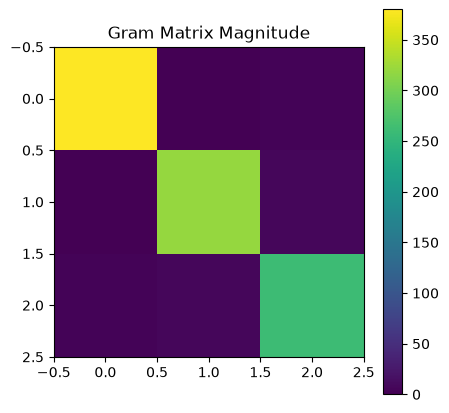

In [23]:
plt.figure(figsize=(5,5))

plt.imshow(np.abs(G))

plt.colorbar()

plt.title("Gram Matrix Magnitude")

In [24]:
for i in range(len(taus)):

    energy = np.sum(np.abs(S[:,i])**2)

    print(energy)

380.0
320.0
260.0


In [25]:
def gram_two_targets(delay):

    S = np.column_stack([

        delay_signal(s,50),

        delay_signal(s,50+delay)

    ])

    G = S.conj().T @ S

    return np.abs(G[0,1])

In [26]:
delays = np.arange(1,150)

corr = []

for d in delays:

    corr.append(
        gram_two_targets(d)
    )

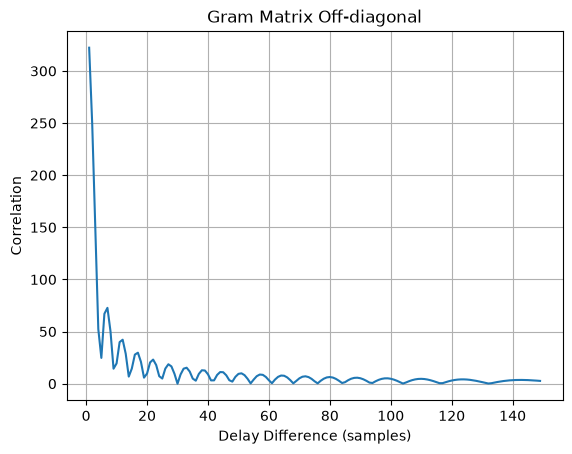

In [27]:
plt.figure()

plt.plot(delays,corr)

plt.xlabel("Delay Difference (samples)")

plt.ylabel("Correlation")

plt.title("Gram Matrix Off-diagonal")

plt.grid()

plt.show()

In [28]:
auto = []

for d in delays:

    auto.append(np.abs(np.vdot(s[:-d],s[d:])))

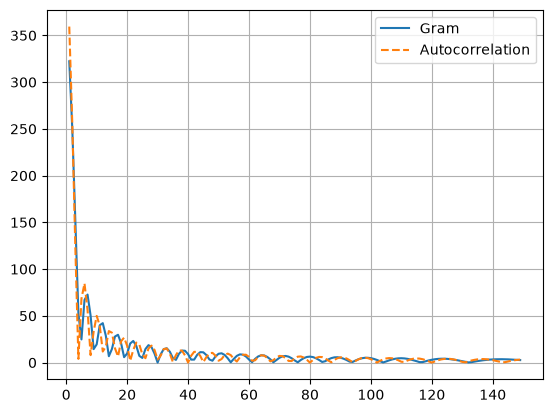

In [29]:
plt.figure()

plt.plot(delays,corr,label="Gram")

plt.plot(delays,auto,'--',label="Autocorrelation")

plt.legend()

plt.grid()

plt.show()

## Discussion

1. The diagonal entries equal signal energy.

2. Off-diagonal entries measure waveform similarity.

3. Increasing target spacing reduces off-diagonal entries.

4. The Gram Matrix off-diagonal follows the waveform autocorrelation.

Therefore,

the Gram Matrix completely characterizes waveform similarity,
which is exactly the theoretical conclusion in Section 3 of the paper.